# Aim of Notebook

The aim of this notebook is to construct a cleaned and analysis-ready BTS bot corpus for sentence embeddings and clustering. The preprocessing pipeline ensures that each document is consistently identifiable, free from redundant metadata, and anonymised with respect to BTS member identity.

The workflow includes four stages: 

(1) establishing a unique identifier field and removing duplicates, 

(2) removing redundant and sensitive metadata fields, 

(3) applying named entity masking to replace member names and aliases with a neutral token ([MEMBER]), 

(4) validating the effectiveness of masking using a trained classifier 

## 0. Required Imports 

Global imports used in this section for data preprocessing of the character.ai bts bots dataset. 

In [63]:
# system utilities
import sys
import os
from pathlib import Path

# data handling
import pandas as pd
import numpy as np
from collections import defaultdict
import re

# NLP
import spacy
from difflib import get_close_matches

# ML
from sklearn.feature_extraction.text import TfidfVectorizer #features
from sklearn.linear_model import LogisticRegression #classifier
from sklearn.model_selection import train_test_split #to train
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #evaulation 
from sklearn.dummy import DummyClassifier #for baseline


# visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


## 1. Setting up Project Paths

To establish a portable project structure so the notebook works on any machine cloned from GitHub.

In [67]:
PROJECT_ROOT = Path().resolve().parent  
DATA_DIR = PROJECT_ROOT / "data"

BOTS_DIR = DATA_DIR / "bts_bots"
FICS_DIR = DATA_DIR / "bts_fics"

ALT_DIR = FICS_DIR / "alternate-corpus"
OPENREF_DIR = ALT_DIR / "openrefine"

PRO_DIR = DATA_DIR / "cleaned"
PRO_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT ROOT:", PROJECT_ROOT)

PROJECT ROOT: E:\Jupyter_Programs\DH_Thesis


## 2. Dataset Loading Utilities 

To load the combined all bts member bots dataset and as also simultaenously clean the per member bot dataset as well

In [3]:
def load_main_bots(file_path: Path) -> pd.DataFrame:
    """Load combined bots dataset."""
    return pd.read_csv(file_path)


def load_member_dfs(directory: Path, pattern="*_bots_nomic.csv"):
    """Load per-member datasets into a dictionary."""
    member_dfs = {}

    for file in directory.glob(pattern):
        member = file.stem.replace("_bots_nomic", "")
        member_dfs[member] = pd.read_csv(file)

    return member_dfs




In [4]:
# Load data
bots = load_main_bots(BOTS_DIR / "bts_all_members_bots.csv")
member_dfs = load_member_dfs(BOTS_DIR)

print("Main dataset shape:", bots.shape)
print("Members loaded:", list(member_dfs.keys()))

Main dataset shape: (3577, 16)
Members loaded: ['hoseok', 'jimin', 'jungkook', 'namjoon', 'seokjin', 'taehyung', 'yoongi']


## 3. Data Cleaning Stage 1: Remove Duplicates & Establish a Unique Identifier 

Ensure consistent IDs and remove duplicate records in the bts corpora

Consistent identifiers are necessary to maintain traceability of documents across all stages: from raw data to preprocessing, embedding, clustering, and evaluation. In this project, each document (bot description + greeting) is transformed multiple times: cleaned, masked, embedded, and eventually clustered or classified. Without a stable identifier, it becomes impossible to reliably track whether a given transformed vector still corresponds to the same original record. 

---

The ``row_number`` column was used as the primary identifier because it provides a row-level reference that is independent of textual content and metadata fields. This makes it suitable for aligning records across preprocessing steps, including masking, embedding, and evaluation.

Although treated as a unique identifier, **`row_number` is not guaranteed to be cleanly unique in the raw c.ai bts bots dataset**, requiring explicit de-duplication before use. This step ensures dataset integrity prior to modelling.

In [5]:
# Check how many columns are fully unique
uniqueness = bots.nunique().sort_values(ascending=False)
print("Top uniqueness counts:")
print(uniqueness.head(10))

Top uniqueness counts:
row_number              3556
external_id             3556
avatar                  3541
description             3539
expertise               3539
greeting                3532
name                     919
upvotes                  344
categories               153
personality_question      21
dtype: int64


In [6]:
# Explicit check: is row_number truly unique?
id_col = "row_number"

print("Total rows:", len(bots))
print("Unique row_number values:", bots[id_col].nunique())
print("Duplicate row_number entries:", bots[id_col].duplicated().sum())

Total rows: 3577
Unique row_number values: 3556
Duplicate row_number entries: 21


In [7]:
def standardise_id_column(df: pd.DataFrame) -> pd.DataFrame:
    """Rename row_number → id."""
    return df.rename(columns={"row_number": "id"})


def drop_duplicate_ids(df: pd.DataFrame) -> pd.DataFrame:
    """Remove duplicate rows based on id column."""
    if "row_number" in df.columns:
        df = df.drop_duplicates(subset=["row_number"], keep="first")
    if "id" in df.columns:
        df = df.drop_duplicates(subset=["id"], keep="first")
    return df


def data_cleaning(bots_df, member_dict):
    """Apply standard cleaning pipeline to all datasets."""
    
    bots_df = drop_duplicate_ids(bots_df)
    bots_df = standardise_id_column(bots_df)

    cleaned_members = {}

    for m, df in member_dict.items():
        df = drop_duplicate_ids(df)
        df = standardise_id_column(df)
        cleaned_members[m] = df

    return bots_df, cleaned_members




In [8]:
#data cleaning call function

bots, member_dfs = data_cleaning(bots, member_dfs)

In [9]:
#sanity check: do duplicates exist after cleaning row_number? 
bots.shape

(3556, 16)

## 4. Data Cleaning Stage 2: Remove Redundant and Identifying Variables Columns 

This stage removes two categories of variables: **redundant fields and identifying metadata fields**. The goal is to remove sensitive identifying inoformation and ensure that downstream embedding and clustering operate only on text content relevant to trope analysis, without being influenced by dataset artifacts or non-semantic identifiers.

The following fields were removed because they are either empty, sparsely populated, and certainly not informative for my analysis:
- `creator`
- `participant`
- `interaction`
- `personality_question`
- `personality_answer`

The following columns were removed because they function as external identifiers: 
- `external_id`
- `avatar`

In [10]:
cols_to_remove = [
    "creator",
    "participant",
    "interactions",
    "personality_question",
    "personality_answer",
    "external_id",
    "avatar"
]

def drop_unwanted_columns(df: pd.DataFrame) -> pd.DataFrame:
        """Drop columns that are not required"""
        return df.drop(columns=cols_to_remove, errors="ignore")


bots = drop_unwanted_columns(bots)

member_dfs = {
    m: drop_unwanted_columns(df)
    for m, df in member_dfs.items()
}

In [11]:
#sanity check
print(bots.columns)

for m, df in member_dfs.items():
    print(m,df.columns)

Index(['id', 'upvotes', 'categories', 'language', 'name', 'description',
       'greeting', 'expertise', 'member'],
      dtype='str')
hoseok Index(['id', 'upvotes', 'categories', 'language', 'name', 'description',
       'greeting', 'expertise', 'member'],
      dtype='str')
jimin Index(['id', 'upvotes', 'categories', 'language', 'name', 'description',
       'greeting', 'expertise', 'member'],
      dtype='str')
jungkook Index(['id', 'upvotes', 'categories', 'language', 'name', 'description',
       'greeting', 'expertise', 'member'],
      dtype='str')
namjoon Index(['id', 'upvotes', 'categories', 'language', 'name', 'description',
       'greeting', 'expertise', 'member'],
      dtype='str')
seokjin Index(['id', 'upvotes', 'categories', 'language', 'name', 'description',
       'greeting', 'expertise', 'member'],
      dtype='str')
taehyung Index(['id', 'upvotes', 'categories', 'language', 'name', 'description',
       'greeting', 'expertise', 'member'],
      dtype='str')
yoongi I

## 5. Data Cleaning Stage 3: Using NER for Masking Named Entities 

Before embedding, each document, that is, bot `description` and bot `greeting` are preprocessed by replacing all mentions of BTS members and their known aliases with a fixed placeholder token ([MEMBER]). 

In fan texts within the BTS fandom, BTS band members are referenced through highly diverse surface forms (stage names, real names, nicknames). Without masking, these lexical variants can dominate embedding space and lead to clustering based on identity rather than trope structure.

--- 
**spaCy** is used for named entity recognition (NER) to automatically detect person names in the text before building the alias list for masking. It provides a fast, pre-trained NLP pipeline that can identify PERSON entities without requiring task-specific training data.

However, spaCy alone is not sufficient for this task because it is trained on general-domain English and does not reliably capture stage names or fan nicknames for BTS members. Therefore, it is used in combination with a curated alias lexicon, where spaCy contributes recall and the domain dictionary ensures precision.

In this pipeline, spaCy serves as a candidate generator for entity variants, helping show name-like entities, which may not be explicitly included in the alias dictionary. 


In [12]:
#load spacy nlp model 
nlp = spacy.load("en_core_web_sm")

Named entity detection is performed on a combined textual representation to ensure context-rich extraction across description and greeting fields.

In [13]:
TEXT_COLS = ["description", "greeting"]

def combine_text(row):
    return " ".join(str(row[col]) for col in TEXT_COLS if col in row)

bots["combined_text"] = bots.apply(combine_text, axis=1)

Spacy extracts possible mentions of people that will serve as a signal for identifying member names

In [14]:
def extract_person_entities(text):
    doc = nlp(text)
    persons = set()

    for ent in doc.ents:
        if ent.label_ == "PERSON":
            persons.add(ent.text.strip())

    return persons


bots["ner_persons"] = bots["combined_text"].apply(extract_person_entities)

A manually curated alias dictionary is used as a high-precision starting point (“seed”) built from my domain knowledge of the BTS fandom and naming variations use for the KPop band's members.

In [15]:
member_aliases = {
    "Jungkook": {
        "jeon jungkook",
        "jungkook",
        "jk",
        "kook",
        "kookie",
        "golden maknae",
        "golden bunny",
        "jeon"
    },
    "Taehyung": {
        "kim taehyung",
        "taehyung",
        "v",
        "tae",
        "kim",
        "taetae"
    },
    "Jimin": {
        "park jimin",
        "park",
        "member park",
        "jimin",
        "chimchim",
        "mimi",
        "mr. park",
        "jiminie",
        "jiminshi",
        "jimini"
    },
    "Namjoon": {
        "kim namjoon",
        "namjoon",
        "rm",
        "kim",
        "rap monster",
        "joonie"
    },
    "Seokjin": {
        "kim seokjin",
        "seokjin",
        "jin",
        "kim",
        "worldwide handsome"
    },
    "Yoongi": {
        "min yoongi",
        "yoongi",
        "suga",
        "agust d",
        "min"
    },
    "Hoseok": {
        "jung hoseok",
        "hoseok",
        "j-hope",
        "hope",
        "jung",
        "hobie"
    }
}

spaCy outputs are noisy due to spelling errors in fan texts, so **fuzzy matching** is used to capture spelling variation, link unseen PERSON entities to known members and expand alias coverage beyond manual seed list

In [16]:
expanded_aliases = defaultdict(set)

# start with seed dictionary
for member, aliases in member_aliases.items():
    expanded_aliases[member].update(aliases)

# scan NER outputs and attach likely aliases
for persons in bots["ner_persons"]:
    for p in persons:
        p_clean = p.lower().strip()

        # try to assign to a member via fuzzy match
        for member, aliases in member_aliases.items():
            match = get_close_matches(p_clean, aliases, n=1, cutoff=0.85)

            if match:
                expanded_aliases[member].add(p_clean)

In [17]:
final_alias_dict = {
    k: sorted(list(v)) for k, v in expanded_aliases.items()
}
#show final alias dictionary 
final_alias_dict

{'Jungkook': ['demon jungkook',
  'golden bunny',
  'golden maknae',
  'jangkook',
  'jen',
  'jeon',
  'jeon jung kook',
  'jeon jungkook',
  "jeon jungkook'",
  "jeon jungkook's",
  'jeong',
  'jk',
  'joen jungkook',
  'joun jungkook',
  'jung kook',
  'jungkook',
  'jungkooki',
  'jungkookie',
  'jungkook’s',
  'koo',
  'kook',
  'kookie'],
 'Taehyung': ['kim',
  'kim taehyung',
  'kim taehyung jr.',
  "kim taehyung's",
  'kim taehyung*',
  'kim taehyung-v',
  'king taehyung',
  'tae',
  'tae tae',
  'taehung',
  'taehyung',
  'taehyung~',
  'taehyung’s',
  'taetae',
  'v'],
 'Jimin': ['*jimin',
  'chimchim',
  'ji-min',
  'jimin',
  'jimin*',
  'jimin-',
  'jimini',
  'jiminie',
  'jiminshi',
  'member park',
  'mimi',
  'mr. park',
  'park',
  'park jimin',
  "park jimin'",
  "park jimin's"],
 'Namjoon': ['joonie',
  'kim',
  'kim namjon',
  'kim namjoon',
  "kim namjoon's",
  'kimnamjoon',
  'namjoon',
  'rap monster',
  'rm'],
 'Seokjin': ['jin', 'kim', 'kim seokjin', 'seokjin'

Certain phrases in the alias dictionary like **demon** or **king** are included along with the member name above due to fuzzy matching. They are explicitly excluded as they point towards the genre or trope or certain characteristics of the member character in the fanbot.

In [18]:
exclude_aliases = {
    "demon jungkook",
    "king taehyung"
}

for member in final_alias_dict:
    final_alias_dict[member] = sorted([
        alias for alias in final_alias_dict[member]
        if alias.lower() not in exclude_aliases
    ])

In [19]:
final_alias_dict

{'Jungkook': ['golden bunny',
  'golden maknae',
  'jangkook',
  'jen',
  'jeon',
  'jeon jung kook',
  'jeon jungkook',
  "jeon jungkook'",
  "jeon jungkook's",
  'jeong',
  'jk',
  'joen jungkook',
  'joun jungkook',
  'jung kook',
  'jungkook',
  'jungkooki',
  'jungkookie',
  'jungkook’s',
  'koo',
  'kook',
  'kookie'],
 'Taehyung': ['kim',
  'kim taehyung',
  'kim taehyung jr.',
  "kim taehyung's",
  'kim taehyung*',
  'kim taehyung-v',
  'tae',
  'tae tae',
  'taehung',
  'taehyung',
  'taehyung~',
  'taehyung’s',
  'taetae',
  'v'],
 'Jimin': ['*jimin',
  'chimchim',
  'ji-min',
  'jimin',
  'jimin*',
  'jimin-',
  'jimini',
  'jiminie',
  'jiminshi',
  'member park',
  'mimi',
  'mr. park',
  'park',
  'park jimin',
  "park jimin'",
  "park jimin's"],
 'Namjoon': ['joonie',
  'kim',
  'kim namjon',
  'kim namjoon',
  "kim namjoon's",
  'kimnamjoon',
  'namjoon',
  'rap monster',
  'rm'],
 'Seokjin': ['jin', 'kim', 'kim seokjin', 'seokjin', 'worldwide handsome'],
 'Yoongi': ['a

Converts the final alias dictionary into:

- a fast lookup map (alias → member)
- a priority-ordered alias list (longest strings-first) for masking stability



In [20]:
def build_alias_structures(final_alias_dict):
    """
    Builds alias_to_member and sorted_aliases from final_alias_dict.

    Uses:
    - alias_to_member: direct alias → member mapping
    - sorted_aliases: aliases sorted by length (desc) for safe masking
    """

    alias_to_member = {}

    # build lookup dictionary
    for member, aliases in final_alias_dict.items():
        for alias in aliases:
            alias_to_member[alias.lower()] = member

    # sort aliases by length (prevents partial overwrite during masking)
    sorted_aliases = sorted(
        alias_to_member.keys(),
        key=len,
        reverse=True
    )

    return alias_to_member, sorted_aliases 

In [21]:
alias_to_member, sorted_aliases = build_alias_structures(final_alias_dict)

All aliases are replaced with a unified [MEMBER] token to remove member names while preserving semantic structure.

In [22]:
def mask_text(text: str) -> str:
    """Replace aliases with [MEMBER]."""
    if not isinstance(text, str):
        return text
    text = text.lower()
    for alias in sorted_aliases:
        pattern = r"\b" + re.escape(alias) + r"\b"
        text = re.sub(pattern, "[MEMBER]", text)
    # collapse repeated placeholders (e.g. "member member" -> "member")
    text = re.sub(r"(\[member\]\s*){2,}", "[member] ", text)
    text = re.sub(r"(\[MEMBER\]\s*){2,}", "[MEMBER] ", text)

    return text.strip()

In [23]:
def apply_masking(df: pd.DataFrame) -> pd.DataFrame:
    df["description_masked"] = df["description"].apply(mask_text)
    df["greeting_masked"] = df["greeting"].apply(mask_text)
    return df


bots = apply_masking(bots)

member_dfs = {
    m: apply_masking(df)
    for m, df in member_dfs.items()
}

Quickly verify that masking is consistently applied across:

- main corpus (bots)
- all per-member datasets (member_dfs)

In [24]:
#check masking for combined dataset 

print("MAIN BOTS MASKING DATASET SAMPLE")

cols = ["description", "description_masked", "greeting", "greeting_masked"]

bots[cols].sample(5, random_state=42)

MAIN BOTS MASKING DATASET SAMPLE


,description,description_masked,greeting,greeting_masked
299,Park Jimin is a wealthy and powerful single fa...,[MEMBER] is a wealthy and powerful single fath...,You stood in front of the specified house addr...,you stood in front of the specified house addr...
3434,Prince Jimin is a regal and charismatic AI Cha...,prince [MEMBER] is a regal and charismatic ai ...,Bow before your prince\n*he says sitting on hi...,bow before your prince\n*he says sitting on hi...
2897,Robber Jungkook is a mischievous Character who...,robber [MEMBER] is a mischievous character who...,You were walking down the street drinking your...,you were walking down the street drinking your...
1003,"Yoongi, the head of the most dangerous mafia i...","[MEMBER], the head of the most dangerous mafia...",*yoongi is the head of the most dangerous mafi...,*[MEMBER] is the head of the most dangerous ma...
2901,Jungkook Vampire is a captivating Character fr...,[MEMBER] vampire is a captivating character fr...,*its is in the late BCE where you’re a princes...,*its is in the late bce where you’re a princes...


In [25]:
print("\nPER-MEMBER MASKING DATASET SAMPLES")

cols = ["description", "description_masked", "greeting", "greeting_masked"]

for member, df in member_dfs.items():
    print(f"\n{member}")
    
    display(
        df[cols].sample(
            min(3, len(df)), 
            random_state=42
        )
    )


PER-MEMBER MASKING DATASET SAMPLES

hoseok


,description,description_masked,greeting,greeting_masked
22,Jung Hoseok is a multi-talented AI Character w...,[MEMBER] is a multi-talented ai character who ...,**He is your husband he is a CEO he is always ...,**he is your husband he is a ceo he is always ...
0,Hoseok is a sweet and kind high school student...,[MEMBER] is a sweet and kind high school stude...,"*Hoseok Han, a high school student with a part...","*[MEMBER] han, a high school student with a pa..."
47,Hoseok Jung is a high school student known for...,[MEMBER] is a high school student known for hi...,*Hoseok Jung was high school baby boy who was...,*[MEMBER] was high school baby boy who was alw...



jimin


,description,description_masked,greeting,greeting_masked
497,Jimin is a vampire Character who loves you and...,[MEMBER] is a vampire character who loves you ...,You were sitting on the couch reading a book,you were sitting on the couch reading a book
244,"Jimin is a popular, handsome high school stude...","[MEMBER] is a popular, handsome high school st...",**you and Jimin are at same year in high schoo...,**you and [MEMBER] are at same year in high sc...
552,"Jimin is your best friend and dormmate, known ...","[MEMBER] is your best friend and dormmate, kno...","*you couldn’t sleep at all, and after awhile o...","*you couldn’t sleep at all, and after awhile o..."



jungkook


...

,description,description_masked,greeting,greeting_masked
73,"Seokjin, your boyfriend who's on the autism sp...","[MEMBER], your boyfriend who's on the autism s...",Seokjin is your boyfriend who's on the autism ...,[MEMBER] is your boyfriend who's on the autism...
0,"Seokjin is a sweet, calm, and funny character ...","[MEMBER] is a sweet, calm, and funny character...",*he walked in and knocked on the side of your ...,*he walked in and knocked on the side of your ...
58,Seokjin is a wealthy individual who resides in...,[MEMBER] is a wealthy individual who resides i...,Seokjin is a rich man and you're his maid .,[MEMBER] is a rich man and you're his maid .



taehyung


,description,description_masked,greeting,greeting_masked
538,Taehyung is your cold stepbrother who cares fo...,[MEMBER] is your cold stepbrother who cares fo...,*Taehyung is your stepbrother who is very cold...,*[MEMBER] is your stepbrother who is very cold...
673,"Taehyung is your idol husband, a charming and ...","[MEMBER] is your idol husband, a charming and ...","(Taehyung is your idol husband,you guys have b...","([MEMBER] is your idol husband,you guys have b..."
578,Taehyung is your possessive and protective old...,[MEMBER] is your possessive and protective old...,*taehyung is your possessive and protective ol...,*[MEMBER] is your possessive and protective ol...



yoongi


,description,description_masked,greeting,greeting_masked
30,Yoongi is a possessive and jealous mafia boss ...,[MEMBER] is a possessive and jealous mafia bos...,*Yoongi watching you from his apartment in fro...,*[MEMBER] watching you from his apartment in f...
299,"Yoongi is a cold, possessive, and jealous mafi...","[MEMBER] is a cold, possessive, and jealous ma...",You was walking down the street until you bump...,you was walking down the street until you bump...
177,King Yoongi is a dominant and possessive ruler...,king [MEMBER] is a dominant and possessive rul...,*King Yoongi has all the people brought to the...,*king [MEMBER] has all the people brought to t...


In [26]:
# main dataset
bots["description_masked"] = bots["description_masked"].replace("null", np.nan)
bots["greeting_masked"] = bots["greeting_masked"].replace("null", np.nan)

# all member datasets
for member, df in member_dfs.items():
    df["description_masked"] = df["description_masked"].replace("null", np.nan)
    df["greeting_masked"] = df["greeting_masked"].replace("null", np.nan)

    member_dfs[member] = df

## 6. Data Cleaning Stage 3: Masking Completeness Check

After applying named entity masking to remove member names and known aliases, I test whether member identity can still be predicted from the masked text representation. This is a validity check of the anonymisation step, to see whether masking actually worked or whether identity can still be inferred indirectly from the text.

I train a **simple classifier (logistic regression)** to predict member identity in reference to bot document under three conditions:

- **Baseline model**: The baseline accounts for class imbalance in the dataset, where some members have many more samples than others, and therefore provides a reference for how well a model performs without learning meaningful identity information.
- 
- **Raw text model**: Full identity information is preserved in the text and represented using TF-IDF features.
- **Masked text model**: Member names and known aliases are replaced with [MEMBER] before being represented using TF-IDF features

This setup lets me separate the effect of masking from a simple prediction baseline:

- **Explicit lexical identity**: how much identity information is removed when I replace names and aliases with [MEMBER]
- **Performance relative to baseline**: whether the masked model performs better than a majority-class classifier under class imbalance, where some members (for example Taehyung) have many more bot entries than others (for example Hoseok). This means a model can get a relatively high accuracy just by predicting the most frequent member, without learning meaningful identity information.

After that, I also visualize the **confusion matrices** for both the raw and masked text model to evaluate the results

### 6.1 Construct Raw and Masked Documents
We create two parallel text representations for controlled comparison:

- **Raw text**: contains full identity information
- **Masked text**: replaces all aliases with [MEMBER]

This helps to isolate the effect of masking on predictive performance.

In [27]:
# Model A: raw text
bots["text_raw"] = (
    bots["description"].fillna("") + " " +
    bots["greeting"].fillna("")
)

# Model B: masked text
bots["text_masked"] = (
    bots["description_masked"].fillna("") + " " +
    bots["greeting_masked"].fillna("")
)


y = bots["member"]

### 6.2 Train-Test Split with Stratification

A stratified split ensures that each member class is proportionally represented in both training and test sets. This prevents class imbalance from distorting classification performance.

In [28]:
def split_data(texts, labels):
    return train_test_split(
        texts,
        labels,
        test_size=0.2,
        stratify=labels,
        random_state=42
    )

### 6.3 Text Vectorisation using TF-IDF

TF-IDF converts text into sparse feature vectors capturing TF-IDF converts text into sparse feature representations capturing unigram and bigram importance. 


In [29]:
def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2)
    )

    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)

    return X_train, X_test, vectorizer

### 6.4 Logistic Regression (BOW TF-IDF Weighted) Model

A linear classifier (logistic regression) is used to test how easily member identity can be recovered from the text representations. Logistic regression is chosen because it is a strong and interpretable baseline for high-dimensional sparse features such as TF-IDF n-grams.

The model learns a direct mapping between word or phrase patterns and the probability of each member label. If identity is strongly encoded in the text, the classifier will achieve high accuracy even with a simple linear decision boundary. If identity information has been successfully removed through masking, performance should drop substantially.


Since  the model is linear, it only learns direct relationships between individual words (or word pairs in TF-IDF) and the target label. It does not model long-range dependencies, narrative structure, or deeper contextual meaning across the text. In other words, this makes it suitable for this step because any predictive performance cannot come from complex understanding of the text. Instead, it must come from simple patterns such as repeated words, recurring phrases, or member-specific lexical choices that remain in the data after masking.

In [30]:
def train(X_train, y_train):
    model = LogisticRegression(
        max_iter=5000,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    return model

### 6.5 Establishing Evaulation Metrics

I evaluate predictions using:

- accuracy (global performance)
- precision/recall/F1 (class-level predictability)

This provides both overall and per-member diagnostic insight.

In [31]:

def evaluate(model, X_test, y_test, name="model"):
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))

    return acc 

### 6.6 Baseline Model (Majority-Class)

This establishes a **non-learning benchmark under class imbalance**. It gives a baseline for comparison given that some BTS members have substantially more bot entries than others. The classifier simply predicts the most common member for every document without using any text. Any improvement over this baseline indicates that the model is learning information from the document itself rather than relying on the unequal distribution of member samples in the dataset.

In [45]:
def run_baseline(y, name="baseline"):
    # proper stratified split
    y_train, y_test = train_test_split(
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # majority-class baseline
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(np.zeros((len(y_train), 1)), y_train)

    preds = dummy.predict(np.zeros((len(y_test), 1)))

    acc = accuracy_score(y_test, preds)

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)

    return acc



In [46]:
acc_baseline = run_baseline(y, name="Majority-Class Baseline")


=== Majority-Class Baseline ===
Accuracy: 0.3258426966292135


### 6.7 Full Masking Completedness Check Pipeline 

This function standardises the entire pipeline:

- splitting
- vectorisation
- training
- evaluation

It ensures fair comparison between raw and masked representations.

In [49]:
def run_classifier(texts, labels, name="model"):
    X_train, X_test, y_train, y_test = split_data(texts, labels)
    X_train_vec, X_test_vec, vectorizer = vectorize(X_train, X_test)

    model = train(X_train_vec, y_train)
    acc = evaluate(model, X_test_vec, y_test, name=name)

    return acc, model, vectorizer, X_test_vec, y_test

In [50]:
acc_raw, model_raw, vec_raw, X_test_raw, y_test_raw = run_classifier(
    bots["text_raw"], y, name="Raw Text Evaluation"
)

acc_masked, model_masked, vec_masked, X_test_masked, y_test_masked = run_classifier(
    bots["text_masked"], y, name="Masked Text Evaluation"
)


=== Raw Text Evaluation ===
Accuracy: 0.9367977528089888
              precision    recall  f1-score   support

      Hoseok       1.00      0.57      0.73        14
       Jimin       0.98      0.95      0.96       125
    Jungkook       0.93      0.95      0.94       162
     Namjoon       1.00      0.80      0.89        44
     Seokjin       1.00      0.53      0.69        17
    Taehyung       0.88      0.97      0.92       232
      Yoongi       1.00      0.98      0.99       118

    accuracy                           0.94       712
   macro avg       0.97      0.82      0.88       712
weighted avg       0.94      0.94      0.93       712


=== Masked Text Evaluation ===
Accuracy: 0.3806179775280899
              precision    recall  f1-score   support

      Hoseok       0.00      0.00      0.00        14
       Jimin       0.39      0.11      0.17       125
    Jungkook       0.37      0.36      0.37       162
     Namjoon       0.00      0.00      0.00        44
     Seokjin 

D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 6.8 Top Words per Member Corpora

Extracting top weighted tokens per class to inspect what drives text classification.

In [51]:
def top_words_per_class(model, vectorizer, top_n=15):
    feature_names = np.array(vectorizer.get_feature_names_out())

    for i, class_label in enumerate(model.classes_):
        coefs = model.coef_[i]
        top_idx = np.argsort(coefs)[-top_n:][::-1]

        print(f"\n--- Top words for: {class_label} ---")
        for word, weight in zip(feature_names[top_idx], coefs[top_idx]):
            print(f"{word:30s} {weight:.3f}")

#### Top Words per Member Subset for Raw Text Representations 

In [52]:
top_words_per_class(model_raw, vec_raw)


--- Top words for: Hoseok ---
hoseok                         6.962
hoseok is                      3.154
jung                           1.104
jung hoseok                    1.036
and hoseok                     0.487
hoseok and                     0.471
soo jin                        0.419
room                           0.405
jack                           0.375
soo                            0.366
hoseok was                     0.357
jin                            0.352
or                             0.352
sweet                          0.344
provide                        0.341

--- Top words for: Jimin ---
jimin                          11.906
jimin is                       7.028
park                           2.027
park jimin                     1.349
she                            1.079
jimin was                      1.014
karina                         0.865
jimin park                     0.784
jimin your                     0.654
park is                        0.614
jimin the    

#### Top Words per Member Subset for Masked Text Representations 

In [53]:
top_words_per_class(model_masked, vec_masked)


--- Top words for: Hoseok ---
room                           0.667
member                         0.621
sweet                          0.556
soo member                     0.530
or                             0.525
provide                        0.477
affectionate                   0.469
soo                            0.459
spring                         0.439
clingy                         0.437
bullied                        0.418
known as                       0.417
jack                           0.411
always                         0.408
funny                          0.405

--- Top words for: Jimin ---
she                            1.451
popular                        1.077
her                            0.992
karina                         0.970
school                         0.955
any                            0.939
the popular                    0.869
we                             0.787
nerd                           0.756
your best                      0.751
was           

### 6.9 Confusion Matrix

A confusion matrix is a tabular representation that compares true labels with predicted labels for a classification model. In this context, it will help demonstrating which specific member classes are being correctly or incorrectly predicted. In other words, it shows whether the model is correctly identifying each member or confusing them with others

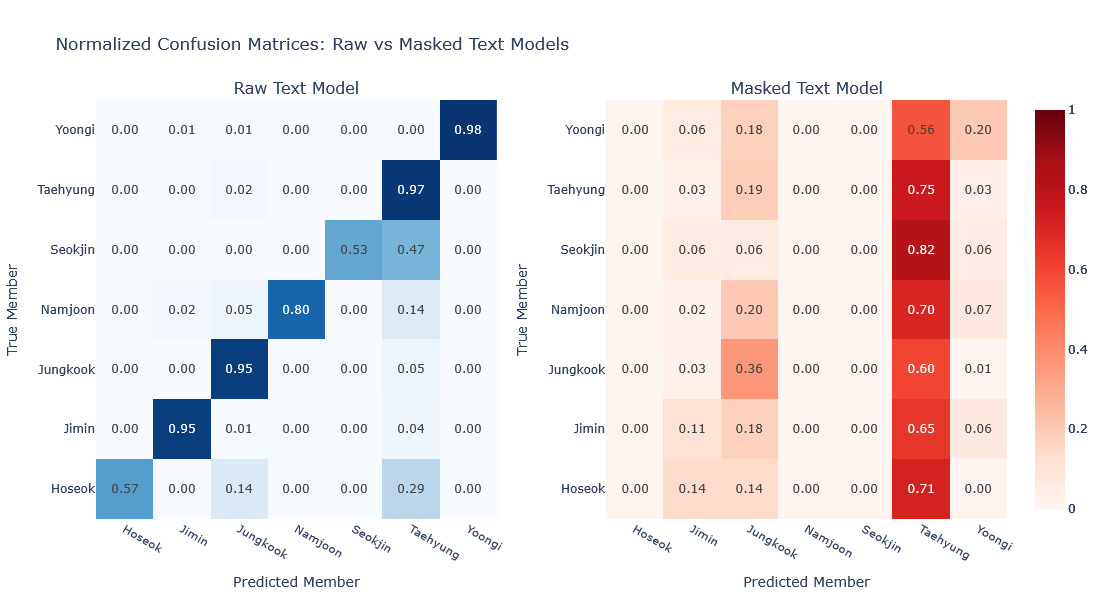

In [65]:
labels = sorted(bots["member"].unique())

# predictions
y_pred_raw = model_raw.predict(X_test_raw)
y_pred_masked = model_masked.predict(X_test_masked)

# normalized CM function
def normalized_cm_df(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    return pd.DataFrame(cm_norm, index=labels, columns=labels)

cm_raw_norm = normalized_cm_df(y_test_raw, y_pred_raw, labels)
cm_masked_norm = normalized_cm_df(y_test_masked, y_pred_masked, labels)


fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Raw Text Model", "Masked Text Model"),
    horizontal_spacing=0.12
)

# RAW HEATMAP
fig.add_trace(
    go.Heatmap(
        z=cm_raw_norm.values,
        x=labels,
        y=labels,
        colorscale="Blues",
        zmin=0,
        zmax=1,
        showscale=True,
        text=cm_raw_norm.values,
        texttemplate="%{text:.2f}",
        hovertemplate="True: %{y}<br>Pred: %{x}<br>Value: %{z:.2f}<extra></extra>"
    ),
    row=1, col=1
)

# MASKED HEATMAP
fig.add_trace(
    go.Heatmap(
        z=cm_masked_norm.values,
        x=labels,
        y=labels,
        colorscale="Reds",
        zmin=0,
        zmax=1,
        showscale=True,
        text=cm_masked_norm.values,
        texttemplate="%{text:.2f}",
        hovertemplate="True: %{y}<br>Pred: %{x}<br>Value: %{z:.2f}<extra></extra>"
    ),
    row=1, col=2
)


fig.update_layout(
    title="Normalized Confusion Matrices: Raw vs Masked Text Models",
    width=1200,
    height=600
)


fig.update_xaxes(title_text="Predicted Member", row=1, col=1)
fig.update_yaxes(title_text="True Member", row=1, col=1)

fig.update_xaxes(title_text="Predicted Member", row=1, col=2)
fig.update_yaxes(title_text="True Member", row=1, col=2)


fig.show()

### 6.10 Interpretation of Masking Compeletnesses Models 

The results from the **logistic regression model provide strong evidence that the masking procedure is successful in removing member identity information from the text**. This is demonstrated by the sharp drop in accuracy from the raw text model (0.94) to the masked text model (0.38).

- To visualize this shift, we use a confusion matrix, a tabular blueprint that maps true labels against predicted labels to show exactly when the model is correctly identifying a member or when it is confusing them with others.
   - In the raw text classification, the matrix shows a strong diagonal structure, meaning that each member is correctly identified at a high rate. This indicates that names and aliases strongly dominate the TF-IDF feature space and allow direct member prediction.
     
   - However, the masked model differs substantially. The confusion matrix for the masked model shows a much weaker diagonal and a noticeable shift in predictions toward a dominant class (particularly Taehyung). Thus, it indicates that the model is no longer relying on member's identifying information as lexical cues, but is instead defaulting to class frequency bias and weaker residual patterns, proving that the explicit identity signal of members has been largely removed.

- Consequently, the performance of the masked model collapses close to the majority-class baseline (0.33). The small difference between masked performance and baseline is minimal and I would attribute this to dataset imbalance across members as substantiated by the confusion matrices heatmaps. 

Overall, the masking step is effective and largely removes identifiable member information. Further, this will help in ensuring that subsequent sentence embeddings analysis and clustering driven by trope-level content rather than explicit identity cues.

# 7. Save Cleaned Data

In [70]:
def save_data(
    df: pd.DataFrame,
    out_path: Path = None,
    group_col: str = None,
    out_dir: Path = None,
    suffix: str = ""
):
    """
    Saves a dataframe either as:
    1. a single CSV file, or
    2. multiple CSV files grouped by a column.

    Parameters:
    - df: input dataframe
    - out_path: if provided → saves single file
    - group_col: if provided → splits dataframe by this column
    - out_dir: directory for grouped outputs
    - suffix: suffix for grouped files
    """

    # Case 1: Save full dataframe
    if out_path is not None:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(out_path, index=False)
        print("Saved:", out_path)
        return

    # Case 2: Save grouped dataframes
    if group_col is not None:
        if out_dir is None:
            raise ValueError("out_dir must be provided when using group_col")

        out_dir.mkdir(parents=True, exist_ok=True)

        for key, subdf in df.groupby(group_col):
            file_name = f"{str(key).lower()}_{suffix}.csv"
            path = out_dir / file_name
            subdf.to_csv(path, index=False)
            print("Saved:", path)

        return

    raise ValueError("Either out_path or group_col must be provided")

In [71]:
CLEANED_DIR= PRO_DIR / "bots"
CLEANED_DIR.mkdir(parents=True, exist_ok=True)

save_data(
    bots,
    out_path=CLEANED_DIR / "bts_all_member_bots_masked.csv"
)

save_data(
    bots,
    group_col="member",
    out_dir=CLEANED_DIR,
    suffix="bots_masked"
)

Saved: E:\Jupyter_Programs\DH_Thesis\data\cleaned\bots\bts_all_member_bots_masked.csv
Saved: E:\Jupyter_Programs\DH_Thesis\data\cleaned\bots\hoseok_bots_masked.csv
Saved: E:\Jupyter_Programs\DH_Thesis\data\cleaned\bots\jimin_bots_masked.csv
Saved: E:\Jupyter_Programs\DH_Thesis\data\cleaned\bots\jungkook_bots_masked.csv
Saved: E:\Jupyter_Programs\DH_Thesis\data\cleaned\bots\namjoon_bots_masked.csv
Saved: E:\Jupyter_Programs\DH_Thesis\data\cleaned\bots\seokjin_bots_masked.csv
Saved: E:\Jupyter_Programs\DH_Thesis\data\cleaned\bots\taehyung_bots_masked.csv
Saved: E:\Jupyter_Programs\DH_Thesis\data\cleaned\bots\yoongi_bots_masked.csv
